# Chapter-Level Similarity Analysis

This notebook builds on notebook 02 by aggregating verse embeddings up to the
**chapter** level.

## Why chapters?

In notebook 02, book-level similarity was computed by averaging the cosine similarity
of every possible verse pair across two books. Mathematically this equals the dot
product of each book's mean embedding. The weakness is that a long, diverse book
(e.g. Psalms, 150 very different poems) produces a mean that points weakly in any
direction, making comparisons noisy.

Chapters give an intermediate resolution: short enough to stay thematically focused,
granular enough to reveal structure *within* books — things like how the tone of a
letter shifts chapter by chapter, or which chapter of Isaiah most closely echoes a
chapter of Romans.

## Approach

1. **Mean-pool** verse embeddings within each chapter → 1,189 chapter vectors
2. **Inspect the norms** of those raw means — this shows how internally consistent
   each chapter is before we normalise
3. **L2-normalise** each chapter vector so all chapters are on equal footing
4. **Compute cosine similarity** between every pair — a 1,189 × 1,189 matrix
   (~5.6 million values, tiny compared to the 3.7 GB verse matrix)

No re-embedding is needed. Everything is derived from the existing verse embeddings.

In [3]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from sacred_semantics.corpus.bible import load_segments
from sacred_semantics.pipeline.embed import load as load_embeddings
from sacred_semantics.corpus.books import BOOKS

segments = load_segments(Path('../data/processed/bible_kjv.json'))
embeddings = load_embeddings(Path('../embeddings/bible_kjv_intfloat_e5_large_v2.npy'))

print(f'Segments:   {len(segments):,}')
print(f'Embeddings: {embeddings.shape}')

Segments:   31,102
Embeddings: (31102, 1024)


## 1. Compute chapter embeddings and inspect norms

For each of the 1,189 chapters we average all its verse embeddings into a single
vector. Before normalising, we plot the **L2 norm** (length) of each raw mean.

- A norm close to 1 means all verses in that chapter point in nearly the same
  semantic direction — the chapter is thematically tight
- A norm close to 0 means the verses scatter in many directions — the chapter is
  thematically diverse

Two plots are shown:

- **Left** — histogram of all chapter norms, with the mean marked in red
- **Right** — norm vs. chapter length, checking whether shorter chapters appear
  more coherent simply because there are fewer verses to average

The most and least coherent chapters are listed below the plots.

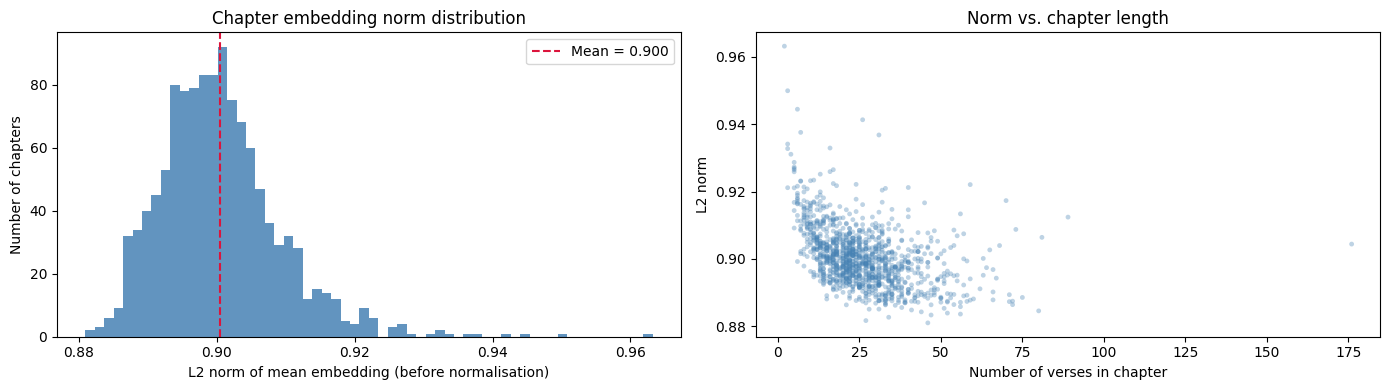

Total chapters : 1189
Norm   — mean: 0.9005  min: 0.8810  max: 0.9632
Length — mean: 26.2  min: 2  max: 176

Most coherent chapters (highest norm):
  Psalms 117  norm=0.9632  (2 verses)
  Psalms 134  norm=0.9499  (3 verses)
  Psalms 150  norm=0.9445  (6 verses)
  Psalms 136  norm=0.9413  (26 verses)
  Psalms  67  norm=0.9376  (7 verses)
  I Chronicles  25  norm=0.9368  (31 verses)
  Esther  10  norm=0.9341  (3 verses)
  Leviticus   2  norm=0.9329  (16 verses)

Least coherent chapters (lowest norm):
  Matthew  22  norm=0.8810  (46 verses)
  Proverbs   7  norm=0.8816  (27 verses)
  Job  21  norm=0.8826  (34 verses)
  Luke  20  norm=0.8833  (47 verses)
  Mark   6  norm=0.8836  (56 verses)
  Luke   2  norm=0.8839  (52 verses)
  Mark  12  norm=0.8842  (44 verses)
  Luke   1  norm=0.8845  (80 verses)


In [4]:
chapter_groups = defaultdict(list)
for i, s in enumerate(segments):
    chapter_groups[(s['book'], s['chapter'])].append(i)

chapter_keys = [
    (book.name, ch)
    for book in BOOKS
    for ch in sorted({s['chapter'] for s in segments if s['book'] == book.name})
]

chapter_embs_raw = np.stack([
    embeddings[chapter_groups[key]].mean(axis=0)
    for key in chapter_keys
])

norms = np.linalg.norm(chapter_embs_raw, axis=1)
chapter_lengths = np.array([len(chapter_groups[key]) for key in chapter_keys])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(norms, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(norms.mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'Mean = {norms.mean():.3f}')
axes[0].set_xlabel('L2 norm of mean embedding (before normalisation)')
axes[0].set_ylabel('Number of chapters')
axes[0].set_title('Chapter embedding norm distribution')
axes[0].legend()

axes[1].scatter(chapter_lengths, norms, alpha=0.35, s=12,
                color='steelblue', edgecolors='none')
axes[1].set_xlabel('Number of verses in chapter')
axes[1].set_ylabel('L2 norm')
axes[1].set_title('Norm vs. chapter length')

plt.tight_layout()
plt.show()

print(f'Total chapters : {len(chapter_keys)}')
print(f'Norm   — mean: {norms.mean():.4f}  min: {norms.min():.4f}  max: {norms.max():.4f}')
print(f'Length — mean: {chapter_lengths.mean():.1f}  min: {chapter_lengths.min()}  max: {chapter_lengths.max()}')

ranked = np.argsort(norms)
print('\nMost coherent chapters (highest norm):')
for i in ranked[-8:][::-1]:
    b, ch = chapter_keys[i]
    print(f'  {b} {ch:>3d}  norm={norms[i]:.4f}  ({chapter_lengths[i]} verses)')
print('\nLeast coherent chapters (lowest norm):')
for i in ranked[:8]:
    b, ch = chapter_keys[i]
    print(f'  {b} {ch:>3d}  norm={norms[i]:.4f}  ({chapter_lengths[i]} verses)')

## 2. Normalise and compute the similarity matrix

Each chapter vector is divided by its own length (L2 normalisation), placing all
1,189 chapters on the surface of a unit sphere. Cosine similarity then reduces to a
plain dot product — fast and simple, no GPU or chunking needed.

The result is saved to disk so this step only runs once.

In [5]:
CHAP_SIM_PATH = Path('../embeddings/bible_kjv_intfloat_e5_large_v2_chapter_similarity.npy')

chapter_embs = chapter_embs_raw / norms[:, np.newaxis]

if CHAP_SIM_PATH.exists():
    print(f'Loading cached matrix from {CHAP_SIM_PATH} ...')
    chap_sim = np.load(CHAP_SIM_PATH)
else:
    print('Computing chapter similarity matrix ...')
    chap_sim = (chapter_embs @ chapter_embs.T).astype(np.float32)
    np.save(CHAP_SIM_PATH, chap_sim)
    print(f'Saved to {CHAP_SIM_PATH}')

print(f'Matrix shape: {chap_sim.shape}  size: {chap_sim.nbytes / 1e6:.1f} MB')

Computing chapter similarity matrix ...
Saved to ..\embeddings\bible_kjv_intfloat_e5_large_v2_chapter_similarity.npy
Matrix shape: (1189, 1189)  size: 5.7 MB


## 3. Genre-level heatmap

The same 10-genre breakdown used in notebook 02, now built from normalised chapter
embeddings. Each cell shows the average cosine similarity between all chapter pairs
drawn from the two genres.

Because the vectors are normalised, this view is purely about **directional
similarity** — which genres "point the same way" in semantic space — and is not
influenced by how internally coherent individual chapters are.

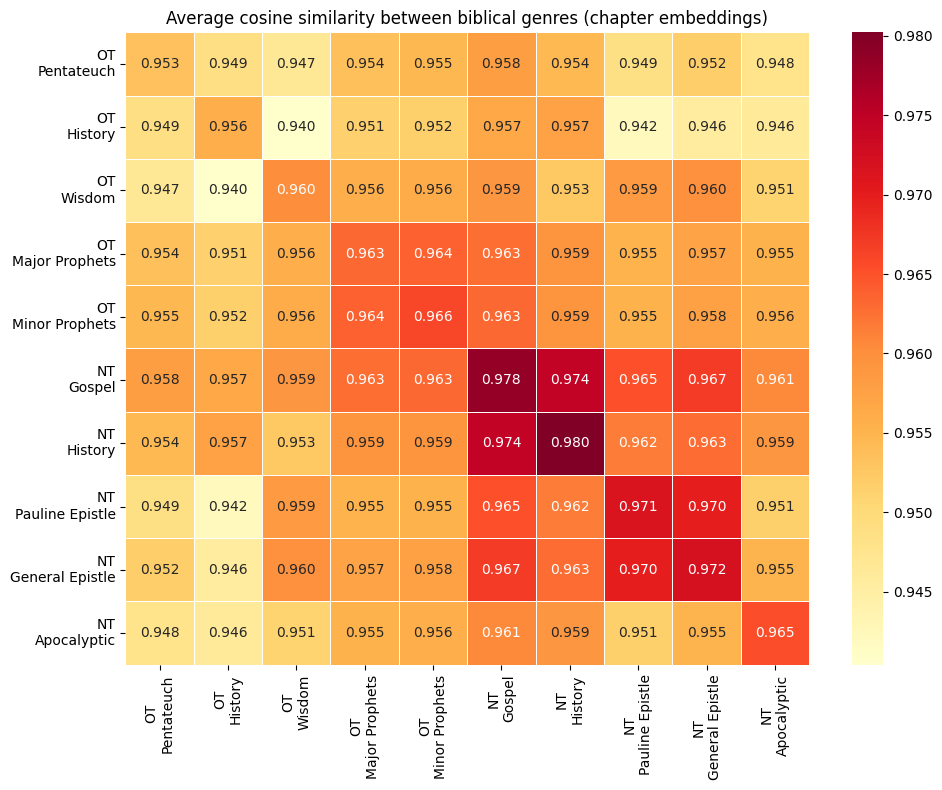

In [6]:
GENRE_ORDER = [
    ('OT', 'Pentateuch'),
    ('OT', 'History'),
    ('OT', 'Wisdom'),
    ('OT', 'Major Prophets'),
    ('OT', 'Minor Prophets'),
    ('NT', 'Gospel'),
    ('NT', 'History'),
    ('NT', 'Pauline Epistle'),
    ('NT', 'General Epistle'),
    ('NT', 'Apocalyptic'),
]

key_to_genre = {
    (s['book'], s['chapter']): (s['testament'], s['genre'])
    for s in segments
}

genre_chapter_indices = {
    g: [i for i, k in enumerate(chapter_keys) if key_to_genre[k] == g]
    for g in GENRE_ORDER
}

n_genres = len(GENRE_ORDER)
genre_sim = np.zeros((n_genres, n_genres))
for i, gi in enumerate(GENRE_ORDER):
    for j, gj in enumerate(GENRE_ORDER):
        block = chap_sim[np.ix_(genre_chapter_indices[gi], genre_chapter_indices[gj])]
        genre_sim[i, j] = block.mean()

genre_labels = [f'{t}\n{g}' for t, g in GENRE_ORDER]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    genre_sim, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=genre_labels, yticklabels=genre_labels,
    ax=ax, vmin=genre_sim.min(), vmax=genre_sim.max(),
    linewidths=0.5, linecolor='white',
)
ax.set_title('Average cosine similarity between biblical genres (chapter embeddings)')
plt.tight_layout()
plt.show()

## 4. Book-level heatmap

All 66 books compared via their chapter embeddings, in canonical order. A white line
separates the Old and New Testaments.

Compare this to the book heatmap in notebook 02 — the pattern should look similar
overall, since both use the same underlying embeddings. Any differences reveal where
the level of aggregation matters.

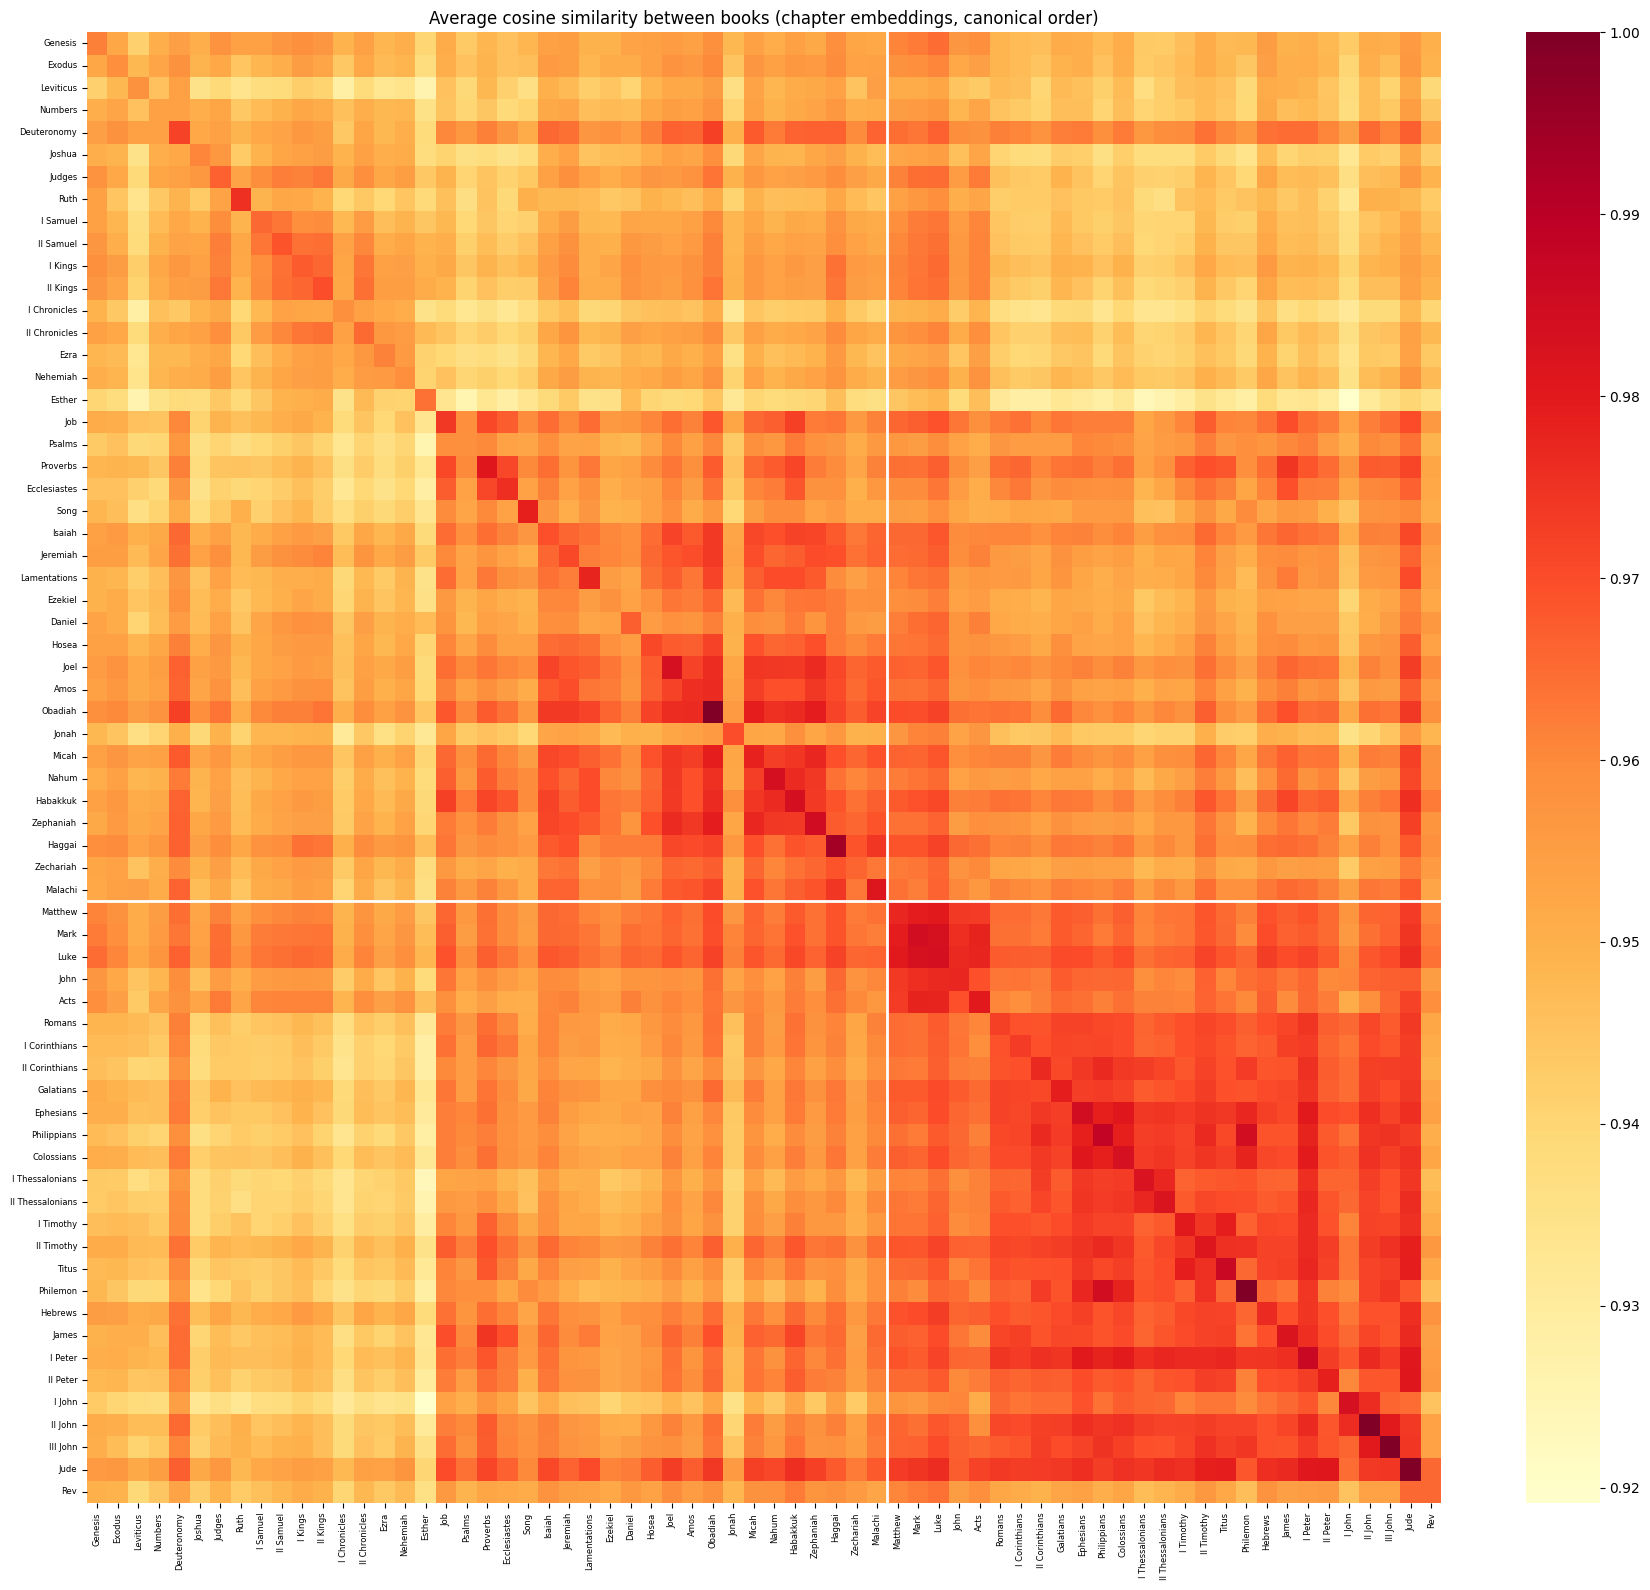

In [7]:
book_names = [b.name for b in BOOKS]

book_chapter_indices = {
    name: [i for i, k in enumerate(chapter_keys) if k[0] == name]
    for name in book_names
}

n_books = len(book_names)
book_sim = np.zeros((n_books, n_books))
for i, bi in enumerate(book_names):
    for j, bj in enumerate(book_names):
        block = chap_sim[np.ix_(book_chapter_indices[bi], book_chapter_indices[bj])]
        book_sim[i, j] = block.mean()

short_labels = [
    b.replace('Song of Solomon', 'Song').replace('Revelation of John', 'Rev')
    for b in book_names
]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    book_sim, cmap='YlOrRd',
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax, vmin=book_sim.min(), vmax=book_sim.max(),
)

ot_count = sum(1 for b in BOOKS if b.testament == 'OT')
ax.axhline(ot_count, color='white', linewidth=2)
ax.axvline(ot_count, color='white', linewidth=2)

ax.set_title('Average cosine similarity between books (chapter embeddings, canonical order)')
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

## 5. Within-book chapter grid

Select a book from the dropdown to see how similar each chapter is to every other
chapter **within the same book**. This view is unique to the chapter level — the
verse matrix was far too large to inspect at this granularity.

**What to look for:**
- A warm diagonal means consecutive chapters share similar themes — common in
  narrative books where a storyline carries forward
- A cool diagonal means chapters are self-contained — common in collections like
  Psalms or Proverbs where each unit stands alone
- Warm off-diagonal blocks reveal chapters that return to an earlier theme, or that
  bracket the book with similar material at beginning and end

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

output_within = widgets.Output()


def show_within_book(book_name: str) -> None:
    with output_within:
        clear_output()
        indices = book_chapter_indices.get(book_name, [])
        if not indices:
            print(f'No chapters found for "{book_name}".')
            return

        block = chap_sim[np.ix_(indices, indices)]
        chapter_numbers = [chapter_keys[i][1] for i in indices]
        n_ch = len(indices)

        fig, ax = plt.subplots(figsize=(max(5, n_ch * 0.38), max(4, n_ch * 0.32)))
        sns.heatmap(
            block,
            annot=(n_ch <= 30), fmt='.2f',
            cmap='YlOrRd',
            xticklabels=chapter_numbers,
            yticklabels=chapter_numbers,
            ax=ax,
            vmin=block.min(), vmax=block.max(),
            linewidths=0.3 if n_ch <= 30 else 0,
            linecolor='white',
        )
        ax.set_title(f'Chapter-to-chapter similarity within {book_name}')
        ax.set_xlabel('Chapter')
        ax.set_ylabel('Chapter')
        plt.tight_layout()
        plt.show()


book_dropdown = widgets.Dropdown(
    options=book_names,
    value='Psalms',
    description='Book:',
    layout=widgets.Layout(width='320px'),
)


def on_book_change(change):
    if change['name'] == 'value':
        show_within_book(change['new'])


book_dropdown.observe(on_book_change)
display(book_dropdown, output_within)
show_within_book('Psalms')

Dropdown(description='Book:', index=18, layout=Layout(width='320px'), options=('Genesis', 'Exodus', 'Leviticus…

Output()

## 6. Find the most similar chapter

Type a chapter reference — e.g. **Psalms 23** or **John 3** — and click Search to
see the ten most similar chapters from anywhere in the Bible.

- Partial book names work: "cor" matches "I Corinthians"
- Capitalisation is ignored
- If you omit the chapter number, chapter 1 is used
- The score is cosine similarity between normalised chapter embeddings:
  1.0 = identical direction, 0.0 = completely unrelated

In [ ]:
output_search = widgets.Output()


def find_similar_chapters(query: str, top_n: int = 10) -> None:
    with output_search:
        clear_output()
        query = query.strip()
        if not query:
            return

        parts = query.rsplit(None, 1)
        if len(parts) == 2 and parts[1].isdigit():
            book_query, chapter_num = parts[0], int(parts[1])
        else:
            book_query, chapter_num = query, None

        lower = book_query.lower()
        exact = [b for b in book_names if b.lower() == lower]
        partial = [b for b in book_names if lower in b.lower()]
        candidates = exact or partial

        if not candidates:
            print(f'No book found matching "{book_query}".')
            return

        matched_book = candidates[0]
        if len(candidates) > 1:
            print(f'Matched "{matched_book}" (others: {", ".join(candidates[1:])})\n')

        if chapter_num is not None:
            key = (matched_book, chapter_num)
            if key not in chapter_groups:
                available = sorted({k[1] for k in chapter_keys if k[0] == matched_book})
                print(f'{matched_book} has no chapter {chapter_num}. Available: {available}')
                return
            query_idx = chapter_keys.index(key)
        else:
            query_idx = next(i for i, k in enumerate(chapter_keys) if k[0] == matched_book)
            b0, ch0 = chapter_keys[query_idx]
            print(f'No chapter specified — using {b0} {ch0}\n')

        sims = chap_sim[query_idx].copy()
        sims[query_idx] = -1
        ranked = np.argsort(sims)[::-1][:top_n]

        b, ch = chapter_keys[query_idx]
        print(f'Top {top_n} chapters most similar to {b} {ch}:\n')
        print(f'  {"Rank":<5} {"Chapter":<35} {"Similarity":>10}')
        print(f'  {"-"*5} {"-"*35} {"-"*10}')
        for rank, j in enumerate(ranked, 1):
            bj, chj = chapter_keys[j]
            ch_ref = f'{bj} {chj}'
            print(f'  {rank:<5} {ch_ref:<35} {sims[j]:>10.4f}')


search_input = widgets.Text(
    placeholder='e.g. Psalms 23  or  John 3',
    description='Chapter:',
    layout=widgets.Layout(width='380px'),
)
search_button = widgets.Button(description='Search', button_style='primary')


def on_search(_):
    find_similar_chapters(search_input.value)


search_button.on_click(on_search)
search_input.on_submit(lambda _: find_similar_chapters(search_input.value))

display(widgets.HBox([search_input, search_button]), output_search)

C:\Users\Joey Kilgore\AppData\Local\Temp\ipykernel_62120\2932725090.py:69: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  search_input.on_submit(lambda _: find_similar_chapters(search_input.value))


Output()